
# EMNIST Digits — GMM CPU/GPU Benchmark
## Standalone, switchable-device notebook

This notebook benchmarks **only Gaussian Mixture Model (GMM)**.

It uses the **same library and same GMM implementation** on both CPU and GPU:

```text
pomegranate.GeneralMixtureModel
```

The only experimental change is:

```python
DEVICE = "cpu"
```

or:

```python
DEVICE = "cuda"
```

### Intended comparison

\[
\boxed{\text{GMM CPU vs GMM GPU}}
\]

### Controlled setup

Both runs use exactly the same:

- EMNIST Digits dataset
- fixed 20,000-image subset
- sample indices
- normalization
- StandardScaler transformation
- 50-dimensional PCA representation
- 10 Gaussian mixture components
- diagonal covariance model
- initial component means
- initial variances
- initial priors
- random seed
- maximum EM iterations
- convergence tolerance
- clustering metrics

Run this notebook once with `DEVICE="cpu"` and save the output.  
Then change **only** `DEVICE` to `"cuda"` and rerun.


## 1. Install packages

In [1]:

import subprocess
import sys
import importlib.util

def ensure_package(module_name, package_name=None):
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name or module_name,
        ])

ensure_package("pomegranate", "pomegranate==1.1.0")
ensure_package("codecarbon")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.4/98.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 113.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 113.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.3.0 requires cryptography<49,>=42, but you have cryptography 50.0.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 50.0.0 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 50.0.0 which is incompatible.


## 2. Imports

In [2]:

import os
import gc
import time
import random
import platform
import threading
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import torch
from torchvision import datasets

import pomegranate
from pomegranate.gmm import GeneralMixtureModel
from pomegranate.distributions import Normal

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    adjusted_rand_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

from codecarbon import EmissionsTracker

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("pomegranate:", getattr(pomegranate, "__version__", "unknown"))
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)


Python: 3.12.13
PyTorch: 2.10.0+cu128
pomegranate: 1.1.0
CUDA available: True
GPU: Tesla T4
CUDA: 12.8



## 3. Choose CPU or GPU

### This is the only line you change between the two experiments

For CPU:

```python
DEVICE = "cpu"
```

For GPU:

```python
DEVICE = "cuda"
```


In [3]:

# ============================================================
# CHANGE ONLY THIS LINE BETWEEN CPU AND GPU EXPERIMENTS
# ============================================================
DEVICE = "cuda"          # "cpu" or "cuda"
# ============================================================

DEVICE = DEVICE.lower().strip()

if DEVICE not in {"cpu", "cuda"}:
    raise ValueError('DEVICE must be either "cpu" or "cuda".')

if DEVICE == "cuda" and not torch.cuda.is_available():
    raise RuntimeError(
        "DEVICE='cuda' was selected but CUDA is unavailable. "
        "On Kaggle, enable Accelerator = GPU."
    )

print("Selected device:", DEVICE.upper())


Selected device: CUDA


## 4. Fixed experimental configuration

In [4]:

SEED = 42

N_SAMPLES = 240_000
PCA_DIMS = 50

N_COMPONENTS = 10

# GMM EM configuration
MAX_ITER = 50
TOL = 0.1

COVARIANCE_TYPE = "diag"
MIN_COV = 1e-4

# Internal metric feasibility
SILHOUETTE_SAMPLE_SIZE = 10_000

CARBON_MEASURE_SECS = 1

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print({
    "device": DEVICE,
    "samples": N_SAMPLES,
    "pca_dims": PCA_DIMS,
    "gmm_components": N_COMPONENTS,
    "max_iter": MAX_ITER,
    "tol": TOL,
    "covariance_type": COVARIANCE_TYPE,
    "seed": SEED,
})


{'device': 'cuda', 'samples': 240000, 'pca_dims': 50, 'gmm_components': 10, 'max_iter': 50, 'tol': 0.1, 'covariance_type': 'diag', 'seed': 42}



## 5. Load the same EMNIST subset

The subset is selected deterministically with `SEED=42`.

Therefore, rerunning the notebook with CPU and then GPU gives the **same exact 20,000 observations**.


In [5]:

dataset = datasets.EMNIST(
    "./data",
    split="digits",
    train=True,
    download=True,
)

rng = np.random.RandomState(SEED)

shared_indices = rng.permutation(
    len(dataset)
)[:N_SAMPLES]

raw_images = dataset.data[
    shared_indices
]

y_true = (
    dataset.targets[
        shared_indices
    ]
    .numpy()
    .astype(np.int32)
)

X_raw = (
    raw_images
    .float()
    .transpose(1, 2)
    .contiguous()
    .view(N_SAMPLES, -1)
    .numpy()
    / 255.0
).astype(np.float32)

print("Full EMNIST train split:", len(dataset))
print("Selected samples:", len(shared_indices))
print("Raw flattened shape:", X_raw.shape)

assert X_raw.shape == (N_SAMPLES, 784)


100%|██████████| 562M/562M [00:02<00:00, 268MB/s]


Full EMNIST train split: 240000
Selected samples: 240000
Raw flattened shape: (240000, 784)


## 6. Shared preprocessing

In [6]:

preprocess_start = time.perf_counter()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_raw
).astype(np.float32)

pca = PCA(
    n_components=PCA_DIMS,
    svd_solver="randomized",
    random_state=SEED,
)

X_pca = pca.fit_transform(
    X_scaled
).astype(np.float32)

preprocessing_time_s = (
    time.perf_counter()
    - preprocess_start
)

X_cpu = torch.from_numpy(
    X_pca
).contiguous()

print("Final clustering matrix:", X_pca.shape)
print("dtype:", X_pca.dtype)
print(f"PCA variance retained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Preprocessing time (excluded from GMM fit): {preprocessing_time_s:.3f} s")


Final clustering matrix: (240000, 50)
dtype: float32
PCA variance retained: 0.7136
Preprocessing time (excluded from GMM fit): 9.553 s


## 7. Dataset preview

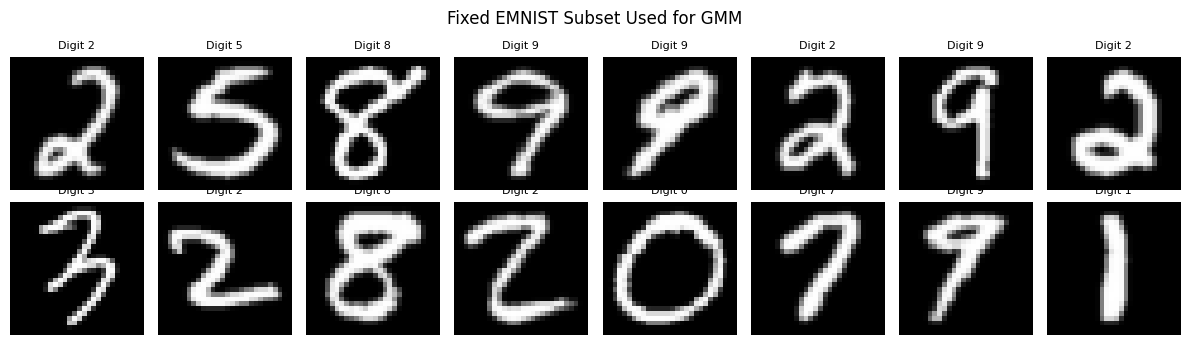

In [7]:

fig, axes = plt.subplots(
    2,
    8,
    figsize=(12, 3.5),
)

for ax, i in zip(
    axes.ravel(),
    range(16),
):
    ax.imshow(
        raw_images[i]
        .transpose(0, 1)
        .numpy(),
        cmap="gray",
    )

    ax.set_title(
        f"Digit {int(y_true[i])}",
        fontsize=8,
    )

    ax.axis("off")

fig.suptitle(
    "Fixed EMNIST Subset Used for GMM"
)

fig.tight_layout()

plt.show()



## 8. Create identical GMM initialization

The CPU and GPU runs must not start from different random Gaussian components.

This notebook creates initialization deterministically from the same PCA matrix:

- **means:** 10 fixed observations selected using `SEED=42`;
- **diagonal variances:** the same global feature-variance vector;
- **priors:** uniform \(1/10\).

Thus when you change `DEVICE`, the starting GMM parameters remain the same.


In [8]:

init_rng = np.random.RandomState(SEED)

mean_indices = init_rng.choice(
    N_SAMPLES,
    size=N_COMPONENTS,
    replace=False,
)

INITIAL_MEANS = X_pca[
    mean_indices
].copy().astype(np.float32)

INITIAL_VARIANCE = np.var(
    X_pca,
    axis=0,
    ddof=0,
).astype(np.float32)

INITIAL_VARIANCE = np.maximum(
    INITIAL_VARIANCE,
    MIN_COV,
).astype(np.float32)

INITIAL_PRIORS = np.full(
    N_COMPONENTS,
    1.0 / N_COMPONENTS,
    dtype=np.float32,
)

print("Initial means:", INITIAL_MEANS.shape)
print("Initial diagonal variance:", INITIAL_VARIANCE.shape)
print("Initial priors:", INITIAL_PRIORS)
print("Initial mean indices:", mean_indices.tolist())


Initial means: (10, 50)
Initial diagonal variance: (50,)
Initial priors: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Initial mean indices: [202827, 151507, 163248, 157083, 69269, 226082, 236614, 127370, 50399, 204569]


## 9. Build the GMM using `pomegranate`

In [9]:

def build_gmm(device):
    components = []

    for component_id in range(N_COMPONENTS):
        distribution = Normal(
            means=torch.from_numpy(
                INITIAL_MEANS[
                    component_id
                ]
            ).clone(),

            covs=torch.from_numpy(
                INITIAL_VARIANCE
            ).clone(),

            covariance_type=COVARIANCE_TYPE,

            min_cov=MIN_COV,
        )

        components.append(
            distribution
        )

    model = GeneralMixtureModel(
        distributions=components,

        priors=torch.from_numpy(
            INITIAL_PRIORS
        ).clone(),

        max_iter=MAX_ITER,

        tol=TOL,

        random_state=SEED,

        verbose=False,
    )

    return model.to(
        device
    )


gmm = build_gmm(
    DEVICE
)

print("Model:", gmm)
print("Model device:", gmm.device)
print("Components:", len(gmm.distributions))


Model: GeneralMixtureModel(
  (distributions): ModuleList(
    (0-9): 10 x Normal()
  )
)
Model device: cuda:0
Components: 10


## 10. Verify initialization before training

In [10]:

means_before = torch.stack([
    distribution.means.detach().cpu()
    for distribution in gmm.distributions
])

covs_before = torch.stack([
    distribution.covs.detach().cpu()
    for distribution in gmm.distributions
])

priors_before = (
    gmm.priors
    .detach()
    .cpu()
)

assert np.allclose(
    means_before.numpy(),
    INITIAL_MEANS,
)

expected_covs = np.repeat(
    INITIAL_VARIANCE[
        None,
        :
    ],
    N_COMPONENTS,
    axis=0,
)

assert np.allclose(
    covs_before.numpy(),
    expected_covs,
)

assert np.allclose(
    priors_before.numpy(),
    INITIAL_PRIORS,
)

print("Initialization verified.")
print("Changing DEVICE does not change starting GMM parameters.")


Initialization verified.
Changing DEVICE does not change starting GMM parameters.


## 11. CodeCarbon and memory tracking

In [11]:

process = psutil.Process(
    os.getpid()
)


def sync():
    if DEVICE == "cuda":
        torch.cuda.synchronize()


class PeakMemory:
    def __init__(self, interval=0.05):
        self.interval = interval
        self.peak_rss = 0
        self.stop_event = threading.Event()
        self.thread = None

    def _watch(self):
        while not self.stop_event.is_set():
            try:
                self.peak_rss = max(
                    self.peak_rss,
                    process.memory_info().rss,
                )
            except Exception:
                pass

            time.sleep(
                self.interval
            )

    def start(self):
        self.peak_rss = (
            process.memory_info().rss
        )

        self.stop_event.clear()

        self.thread = threading.Thread(
            target=self._watch,
            daemon=True,
        )

        self.thread.start()

    def stop(self):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join(
                timeout=2
            )

        return (
            self.peak_rss
            / (1024 ** 2)
        )


def make_tracker():
    kwargs = dict(
        project_name=f"EMNIST-GMM-{DEVICE}",
        measure_power_secs=CARBON_MEASURE_SECS,
        tracking_mode="process",

        # CPU run must not count an attached idle GPU.
        # CUDA run explicitly monitors GPU 0.
        gpu_ids=[0] if DEVICE == "cuda" else [],

        log_level="error",
    )

    try:
        return EmissionsTracker(
            output_methods=[],
            **kwargs,
        )

    except TypeError:
        return EmissionsTracker(
            save_to_file=False,
            save_to_api=False,
            **kwargs,
        )


def environmental_values(tracker):
    data = getattr(
        tracker,
        "final_emissions_data",
        None,
    )

    def attr(name):
        if data is None:
            return np.nan

        value = getattr(
            data,
            name,
            np.nan,
        )

        return (
            np.nan
            if value is None
            else value
        )

    return {
        "energy_kwh": attr("energy_consumed"),
        "co2_kg": attr("emissions"),
        "cpu_energy_kwh": attr("cpu_energy"),
        "gpu_energy_kwh": attr("gpu_energy"),
        "ram_energy_kwh": attr("ram_energy"),
        "cpu_power_w": attr("cpu_power"),
        "gpu_power_w": attr("gpu_power"),
        "country": (
            getattr(data, "country_name", None)
            if data is not None
            else None
        ),
    }



## 12. Move data to selected device

Data-transfer time is recorded separately.

For CPU, `.to("cpu")` is effectively negligible.  
For GPU, this measures the host-to-GPU tensor transfer.

The GMM **fit timer starts after this transfer**, so you get both:

- pure GMM `fit_time_s`;
- data-transfer overhead separately.


In [12]:

sync()

transfer_start = time.perf_counter()

X_device = X_cpu.to(
    DEVICE
)

sync()

data_transfer_s = (
    time.perf_counter()
    - transfer_start
)

print(
    f"Data transfer to {DEVICE.upper()}: "
    f"{data_transfer_s:.6f} s"
)

print(
    "Tensor device:",
    X_device.device,
)


Data transfer to CUDA: 0.011485 s
Tensor device: cuda:0


## 13. GPU warm-up

In [13]:

if DEVICE == "cuda":
    # Warm CUDA context outside timing and energy measurement.
    warm = (
        X_device[:512]
        * 1.0
    ).sum()

    sync()

    del warm

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    print("CUDA warm-up complete.")
else:
    print("CPU selected; CUDA warm-up not required.")


CUDA warm-up complete.


## 14. Fit GMM — measured section

In [14]:

tracker = make_tracker()
memory = PeakMemory()

tracker.start()
memory.start()

sync()

fit_start = time.perf_counter()

gmm.fit(
    X_device
)

sync()

fit_time_s = (
    time.perf_counter()
    - fit_start
)

peak_process_ram_mb = (
    memory.stop()
)

tracker.stop()

environmental = environmental_values(
    tracker
)

peak_gpu_mb = np.nan

if DEVICE == "cuda":
    peak_gpu_mb = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 2)
    )

print(f"GMM fit time: {fit_time_s:.3f} s")
print(f"Peak process RAM: {peak_process_ram_mb:.2f} MB")

if DEVICE == "cuda":
    print(f"Peak GPU memory: {peak_gpu_mb:.2f} MB")

print("Energy (kWh):", environmental["energy_kwh"])
print("CO2e (kg):", environmental["co2_kg"])


[codecarbon WARNING @ 17:10:15] Multiple instances of codecarbon are allowed to run at the same time.


GMM fit time: 3.408 s
Peak process RAM: 3405.34 MB
Peak GPU memory: 203.29 MB
Energy (kWh): 7.135640483290805e-05
CO2e (kg): 1.5593832939080493e-05


## 15. Predict cluster assignments

In [15]:

predict_start = time.perf_counter()

with torch.no_grad():
    labels_device = gmm.predict(
        X_device
    )

sync()

prediction_time_s = (
    time.perf_counter()
    - predict_start
)

labels = (
    labels_device
    .detach()
    .cpu()
    .numpy()
    .astype(
        np.int32,
        copy=False,
    )
)

print("Prediction time:", prediction_time_s, "s")
print("Unique GMM components:", np.unique(labels).tolist())
print("Number of assigned components:", len(np.unique(labels)))


Prediction time: 0.0371538649999934 s
Unique GMM components: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of assigned components: 10


## 16. Robust clustering metrics

In [16]:

def make_safe_silhouette_sample(
    labels,
    max_samples,
    seed,
):
    labels = np.asarray(labels)

    unique_labels = np.unique(
        labels
    )

    n = len(labels)

    if (
        n < 3
        or len(unique_labels) < 2
        or len(unique_labels) >= n
    ):
        return None

    rng = np.random.RandomState(
        seed
    )

    target_n = min(
        max_samples,
        n,
    )

    chosen = []

    # Guarantee at least one point from each component.
    for component_id in unique_labels:
        candidates = np.flatnonzero(
            labels == component_id
        )

        if len(candidates) > 0:
            chosen.append(
                int(
                    rng.choice(
                        candidates
                    )
                )
            )

    chosen = np.asarray(
        chosen,
        dtype=np.int64,
    )

    remaining = (
        target_n
        - len(chosen)
    )

    if remaining > 0:
        all_indices = np.arange(
            n
        )

        available = np.setdiff1d(
            all_indices,
            chosen,
            assume_unique=False,
        )

        extra = rng.choice(
            available,
            size=min(
                remaining,
                len(available),
            ),
            replace=False,
        )

        chosen = np.concatenate(
            [
                chosen,
                extra,
            ]
        )

    rng.shuffle(
        chosen
    )

    if len(np.unique(labels[chosen])) < 2:
        return None

    return chosen


nmi = normalized_mutual_info_score(
    y_true,
    labels,
)

ami = adjusted_mutual_info_score(
    y_true,
    labels,
)

ari = adjusted_rand_score(
    y_true,
    labels,
)

homogeneity = homogeneity_score(
    y_true,
    labels,
)

completeness = completeness_score(
    y_true,
    labels,
)

v_measure = v_measure_score(
    y_true,
    labels,
)


silhouette = np.nan
davies_bouldin = np.nan
calinski_harabasz = np.nan

unique_labels = np.unique(
    labels
)

if (
    len(unique_labels) >= 2
    and len(unique_labels) < len(labels)
):
    sample_idx = make_safe_silhouette_sample(
        labels,
        SILHOUETTE_SAMPLE_SIZE,
        SEED,
    )

    if sample_idx is not None:
        try:
            silhouette = silhouette_score(
                X_pca[
                    sample_idx
                ],
                labels[
                    sample_idx
                ],
            )
        except ValueError:
            silhouette = np.nan

    try:
        davies_bouldin = davies_bouldin_score(
            X_pca,
            labels,
        )
    except ValueError:
        pass

    try:
        calinski_harabasz = calinski_harabasz_score(
            X_pca,
            labels,
        )
    except ValueError:
        pass


print({
    "NMI": nmi,
    "AMI": ami,
    "ARI": ari,
    "homogeneity": homogeneity,
    "completeness": completeness,
    "V-measure": v_measure,
    "silhouette": silhouette,
    "Davies-Bouldin": davies_bouldin,
    "Calinski-Harabasz": calinski_harabasz,
})


{'NMI': np.float64(0.3370635287376067), 'AMI': np.float64(0.3370109296693055), 'ARI': 0.1721803376175299, 'homogeneity': np.float64(0.31143685431839263), 'completeness': np.float64(0.36728574584896734), 'V-measure': np.float64(0.33706352873760664), 'silhouette': np.float32(-0.00853614), 'Davies-Bouldin': np.float64(3.835241883173535), 'Calinski-Harabasz': np.float32(5254.0654)}


## 17. Final result table

In [17]:

result = {
    "algorithm":
        "GMM",

    "library":
        "pomegranate",

    "device":
        DEVICE,

    "seed":
        SEED,

    "samples":
        N_SAMPLES,

    "features_after_pca":
        PCA_DIMS,

    "components":
        N_COMPONENTS,

    "covariance_type":
        COVARIANCE_TYPE,

    "max_iter":
        MAX_ITER,

    "tol":
        TOL,

    "preprocessing_time_s":
        preprocessing_time_s,

    "data_transfer_s":
        data_transfer_s,

    "fit_time_s":
        fit_time_s,

    "fit_throughput_samples_s":
        N_SAMPLES
        / fit_time_s,

    "prediction_time_s":
        prediction_time_s,

    "n_components_found":
        len(
            np.unique(
                labels
            )
        ),

    "nmi":
        nmi,

    "ami":
        ami,

    "ari":
        ari,

    "homogeneity":
        homogeneity,

    "completeness":
        completeness,

    "v_measure":
        v_measure,

    "silhouette":
        silhouette,

    "davies_bouldin":
        davies_bouldin,

    "calinski_harabasz":
        calinski_harabasz,

    "peak_process_ram_mb":
        peak_process_ram_mb,

    "peak_gpu_mb":
        peak_gpu_mb,

    "energy_kwh":
        environmental[
            "energy_kwh"
        ],

    "co2_kg":
        environmental[
            "co2_kg"
        ],

    "co2_g":
        (
            environmental[
                "co2_kg"
            ]
            * 1000
            if pd.notna(
                environmental[
                    "co2_kg"
                ]
            )
            else np.nan
        ),

    "cpu_energy_kwh":
        environmental[
            "cpu_energy_kwh"
        ],

    "gpu_energy_kwh":
        environmental[
            "gpu_energy_kwh"
        ],

    "ram_energy_kwh":
        environmental[
            "ram_energy_kwh"
        ],

    "cpu_power_w":
        environmental[
            "cpu_power_w"
        ],

    "gpu_power_w":
        environmental[
            "gpu_power_w"
        ],

    "carbon_country":
        environmental[
            "country"
        ],
}

result_df = pd.DataFrame(
    [result]
)

display(
    result_df.round(6)
)


,algorithm,library,device,seed,samples,features_after_pca,components,covariance_type,max_iter,tol,preprocessing_time_s,data_transfer_s,fit_time_s,fit_throughput_samples_s,prediction_time_s,n_components_found,nmi,ami,ari,homogeneity,completeness,v_measure,silhouette,davies_bouldin,calinski_harabasz,peak_process_ram_mb,peak_gpu_mb,energy_kwh,co2_kg,co2_g,cpu_energy_kwh,gpu_energy_kwh,ram_energy_kwh,cpu_power_w,gpu_power_w,carbon_country
0,GMM,pomegranate,cuda,42,240000,50,10,diag,50,0.1,9.552746,0.011485,3.408243,70417.521537,0.037154,10,0.337064,0.337011,0.17218,0.311437,0.367286,0.337064,-0.008536,3.835242,5254.06543,3405.34375,203.285156,0.000071,0.000016,0.015594,0.000004,0.000058,0.000009,3.125914,50.142273,United States


## 18. PCA cluster visualization

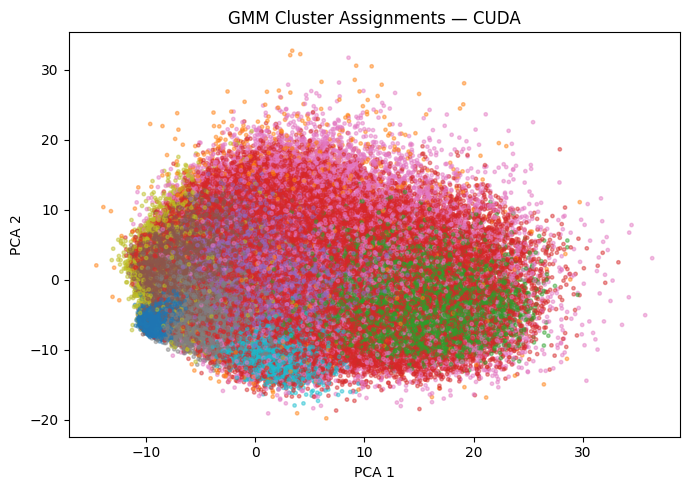

In [18]:

fig, ax = plt.subplots(
    figsize=(7, 5),
)

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=6,
    alpha=0.45,
    cmap="tab10",
)

ax.set_title(
    f"GMM Cluster Assignments — {DEVICE.upper()}"
)

ax.set_xlabel(
    "PCA 1"
)

ax.set_ylabel(
    "PCA 2"
)

fig.tight_layout()

plt.show()


## 19. Component sizes

,component,count,fraction
0,0,17983,0.074929
1,1,1921,0.008004
2,2,12137,0.050571
3,3,76164,0.317350
4,4,34512,0.143800
5,5,40584,0.169100
6,6,19541,0.081421
7,7,25108,0.104617
8,8,5368,0.022367
9,9,6682,0.027842


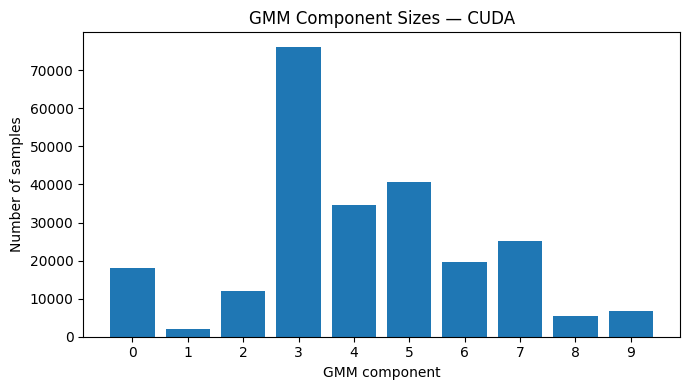

In [19]:

cluster_ids, cluster_counts = np.unique(
    labels,
    return_counts=True,
)

component_df = pd.DataFrame({
    "component":
        cluster_ids,

    "count":
        cluster_counts,

    "fraction":
        cluster_counts
        / len(labels),
})

display(
    component_df
)

fig, ax = plt.subplots(
    figsize=(7, 4),
)

ax.bar(
    component_df[
        "component"
    ].astype(str),
    component_df[
        "count"
    ],
)

ax.set_title(
    f"GMM Component Sizes — {DEVICE.upper()}"
)

ax.set_xlabel(
    "GMM component"
)

ax.set_ylabel(
    "Number of samples"
)

fig.tight_layout()

plt.show()



## 20. Save this device's result

The result is saved with the device in the filename:

```text
gmm_emnist_cpu_result.csv
```

or:

```text
gmm_emnist_cuda_result.csv
```

This means you can:

1. run once with `DEVICE="cpu"`;
2. save/download the CPU CSV;
3. change only the device to `"cuda"`;
4. rerun and obtain the GPU CSV.


In [20]:

output_dir = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path(".")
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

result_path = (
    output_dir
    / f"gmm_emnist_{DEVICE}_result.csv"
)

result_df.to_csv(
    result_path,
    index=False,
)

labels_path = (
    output_dir
    / f"gmm_emnist_{DEVICE}_labels.npy"
)

np.save(
    labels_path,
    labels,
)

print("Saved result:", result_path)
print("Saved labels:", labels_path)


Saved result: /kaggle/working/gmm_emnist_cuda_result.csv
Saved labels: /kaggle/working/gmm_emnist_cuda_labels.npy



## 21. Optional CPU-vs-GPU comparison

If both result CSVs exist in the current Kaggle working directory, this cell compares them.

If only one exists, it simply tells you to run the other device.


In [21]:

cpu_path = (
    output_dir
    / "gmm_emnist_cpu_result.csv"
)

gpu_path = (
    output_dir
    / "gmm_emnist_cuda_result.csv"
)

if cpu_path.exists() and gpu_path.exists():

    cpu_result = pd.read_csv(
        cpu_path
    ).iloc[0]

    gpu_result = pd.read_csv(
        gpu_path
    ).iloc[0]

    speedup = (
        cpu_result[
            "fit_time_s"
        ]
        /
        gpu_result[
            "fit_time_s"
        ]
    )

    energy_saving_pct = (
        (
            cpu_result[
                "energy_kwh"
            ]
            -
            gpu_result[
                "energy_kwh"
            ]
        )
        /
        cpu_result[
            "energy_kwh"
        ]
        * 100
        if cpu_result[
            "energy_kwh"
        ] > 0
        else np.nan
    )

    carbon_saving_pct = (
        (
            cpu_result[
                "co2_kg"
            ]
            -
            gpu_result[
                "co2_kg"
            ]
        )
        /
        cpu_result[
            "co2_kg"
        ]
        * 100
        if cpu_result[
            "co2_kg"
        ] > 0
        else np.nan
    )

    comparison = pd.DataFrame([
        {
            "metric":
                "Fit time (s)",

            "CPU":
                cpu_result[
                    "fit_time_s"
                ],

            "GPU":
                gpu_result[
                    "fit_time_s"
                ],
        },
        {
            "metric":
                "Energy (kWh)",

            "CPU":
                cpu_result[
                    "energy_kwh"
                ],

            "GPU":
                gpu_result[
                    "energy_kwh"
                ],
        },
        {
            "metric":
                "CO2e (g)",

            "CPU":
                cpu_result[
                    "co2_g"
                ],

            "GPU":
                gpu_result[
                    "co2_g"
                ],
        },
        {
            "metric":
                "NMI",

            "CPU":
                cpu_result[
                    "nmi"
                ],

            "GPU":
                gpu_result[
                    "nmi"
                ],
        },
        {
            "metric":
                "ARI",

            "CPU":
                cpu_result[
                    "ari"
                ],

            "GPU":
                gpu_result[
                    "ari"
                ],
        },
    ])

    display(
        comparison.round(6)
    )

    print(
        f"GPU speedup = {speedup:.3f}x"
    )

    print(
        f"GPU energy saving = {energy_saving_pct:.2f}%"
    )

    print(
        f"GPU carbon saving = {carbon_saving_pct:.2f}%"
    )

else:
    print(
        "Both result files are not present yet."
    )

    print(
        "Run once with DEVICE='cpu' and once with DEVICE='cuda'."
    )


Both result files are not present yet.
Run once with DEVICE='cpu' and once with DEVICE='cuda'.



# Correct interpretation

The notebook changes only the computational device:

\[
\boxed{\text{pomegranate GMM on CPU}}
\]

versus:

\[
\boxed{\text{pomegranate GMM on GPU}}
\]

The data, initialization and GMM configuration remain fixed.

### Important notes

- `fit_time_s` excludes preprocessing and host-to-GPU transfer.
- `data_transfer_s` is reported separately.
- CodeCarbon measures the GMM fitting region.
- CPU CodeCarbon explicitly excludes the attached GPU.
- GPU CodeCarbon explicitly monitors GPU 0.
- True EMNIST digit labels are used only after clustering to calculate NMI, AMI, ARI and related evaluation metrics.
- CPU and CUDA floating-point kernels may still produce very small numerical differences even though the same library, data and initialization are used.
